# Introduction to Single-Neuron Reconstruction Data

This script serves as a basic introduction to the single-neuron reconstruction (SNR) data.

Let's start by loading the libraries.

In [1]:
# Load Libraries

# data manipulation 
import pandas as pd
import numpy as np

# plotting
import seaborn as sns
import matplotlib.pyplot as plt

# neuron visualizations
from brainrender import Scene
from brainrender.actors import Points

import vedo
vedo.settings.default_backend= 'vtk'

This dataset describes the projections of neurons in L5a of the Entorhinal Cortex.
These neurons have been divided into three major groups, depending on whether they project to RSP, ORB, or both.

In [2]:
# load data
ec_snr_data = pd.read_csv("master_detailed_comment.csv")

ec_snr_data.head()

,mouseID,neuronNR,neuron_ID,FRP_endpoint,FRP_length,SS_endpoint,SS_length,VIS_endpoint,VIS_length,VISpor_endpoint,...,STRd_length,STRv_endpoint,STRv_length,x,y,z,comment,injection,proj,count
0,1056,2,1056_2,0,52.590655,0,0.00000,4,2850.742552,9,...,35586.500280,79,70750.246650,9662.4,3506.8,9755.3,NaN,ORB,rsp_orb,6
1,1056,41,1056_41,0,0.000000,0,0.00000,7,3031.117311,1,...,8835.140534,7,10849.726100,9791.9,3825.0,9756.8,NaN,ORB,rsp_orb,5
2,1056,6,1056_6,0,133.352838,15,15402.66771,11,12446.070610,1,...,57612.283980,71,69422.052800,9680.9,3897.0,9768.1,NaN,ORB,rsp_orb,8
3,1056,26,1056_26,0,0.000000,1,140.00601,11,9656.228320,17,...,30481.705940,16,7439.897194,9844.7,3033.5,9482.4,NA injection area has 0 endpoints injection ar...,ORB,NaN,6
4,1056,31,1056_31,0,148.433770,0,0.00000,0,0.000000,0,...,26718.999420,81,75650.137140,9232.8,4481.3,10019.4,NaN,ORB,orb,3


In [3]:
ec_snr_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 68 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mouseID          237 non-null    int64  
 1   neuronNR         237 non-null    int64  
 2   neuron_ID        237 non-null    object 
 3   FRP_endpoint     237 non-null    int64  
 4   FRP_length       237 non-null    float64
 5   SS_endpoint      237 non-null    int64  
 6   SS_length        237 non-null    float64
 7   VIS_endpoint     237 non-null    int64  
 8   VIS_length       237 non-null    float64
 9   VISpor_endpoint  237 non-null    int64  
 10  VISpor_length    237 non-null    float64
 11  RSP_endpoint     237 non-null    int64  
 12  RSP_length       237 non-null    float64
 13  PTLp_endpoint    237 non-null    int64  
 14  PTLp_length      237 non-null    float64
 15  ORB_endpoint     237 non-null    int64  
 16  ORB_length       237 non-null    float64
 17  MO_endpoint     

This dataset contains the tracing information for 237 neurons, extracted from 11 brains.

- `mouseID` indicates the brain each neuron originates from. 
- `neuronNR` provides each neuron with a unique ID, within its respective brain of origin.
- `neuron_ID` combines `mouseID` and `neuronNR` into a unique identifier for each neuron in the dataset.

The projection area variables are distinguished by two possible suffixes: `_endpoint`, and `_length`.
- `_endpoint`: indicates the number of axon terminals (endpoints) observed in a given projection area, for each neuron.
- `_length`: indicates the total length of axon observed in a given projection area, for each neuron.

The `x`, `y`, and `z` coordinates indicate the location of each neuron's cell body within the Allen Atlas Common Coordinate Framework.

- `injection`: indicates whether a neuron was back-labelled from ORB, or RSP.

- `proj`: Divides neurons into one of three groups, depending on whether they project to ORB, RSP, or both. 

Note that we were unable to confidently assign all neurons into a projection group, leading to NaN entries in this column (only 160 non-null entries for `proj`). An **objective and possible direction** for students would be to _fill these NaNs_. For example, this could involve fitting a classification model to prediction projection group based on the observed neuron characteristics.  

Now we will divide the SNR neurons into their projection groups, and visualize them within brainrender.

In [4]:
# Extract Seperate Projection Group Tables
orb_proj_neurons = ec_snr_data[ec_snr_data["proj"] == "orb"]

rsp_proj_neurons = ec_snr_data[ec_snr_data["proj"] == "rsp"]

rsp_orb_proj_neurons = ec_snr_data[ec_snr_data["proj"] == "rsp_orb"]

nan_proj_neurons = ec_snr_data[ec_snr_data["proj"].isnull()]

In [5]:
# Brainrender Visuzliation
orb_points = Points(np.array(orb_proj_neurons[['x', 'y', 'z']]),
                     radius=20, colors="blue")

rsp_points = Points(np.array(rsp_proj_neurons[['x', 'y', 'z']]),
                     radius=20, colors="orange")

rsp_orb_points = Points(np.array(rsp_orb_proj_neurons[['x', 'y', 'z']]),
                     radius=20, colors="green")

nan_points = Points(np.array(nan_proj_neurons[['x', 'y', 'z']]),
                     radius=20, colors="red")

# Create a brainrender scene
scene = Scene(atlas_name="allen_mouse_25um", title="SNR Data Visualization")

# add neurons
scene.add(orb_points)
scene.add(rsp_points)
scene.add(rsp_orb_points)
scene.add(nan_points)

# add canonial MEC and LEC region meshes
lec = scene.add_brain_region("ENTl", alpha=0.1, color="blue")
mec = scene.add_brain_region("ENTm", alpha=0.1, color="blue")

scene.add(lec)
scene.add(mec)

# Render
scene.render()

Let's visualize histograms of the end points and lengths for different regions.

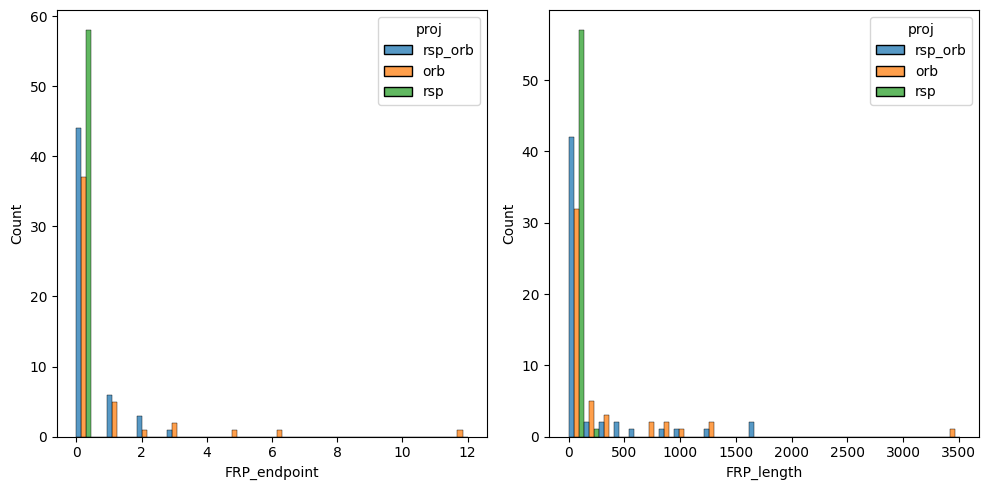

In [6]:
# Visualize the distribution of end points and lengths colored by projection type
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(data=ec_snr_data, x='FRP_endpoint', hue='proj', multiple='dodge', ax=axes[0])
sns.histplot(data=ec_snr_data, x='FRP_length', hue='proj', multiple='dodge', ax=axes[1])
plt.tight_layout()
plt.show()

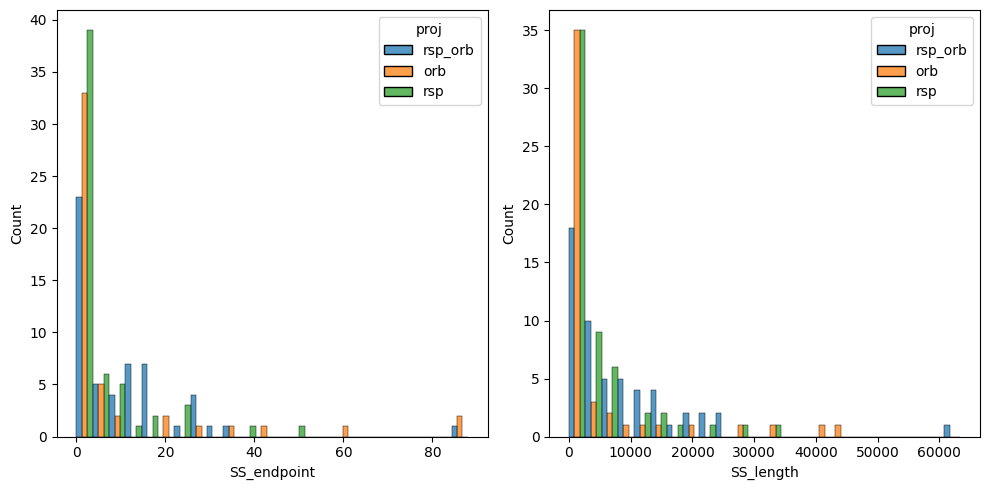

In [7]:
# Visualize the distribution of end points and lengths colored by projection type
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(data=ec_snr_data, x='SS_endpoint', hue='proj', multiple='dodge', ax=axes[0])
sns.histplot(data=ec_snr_data, x='SS_length', hue='proj', multiple='dodge', ax=axes[1])
plt.tight_layout()
plt.show()

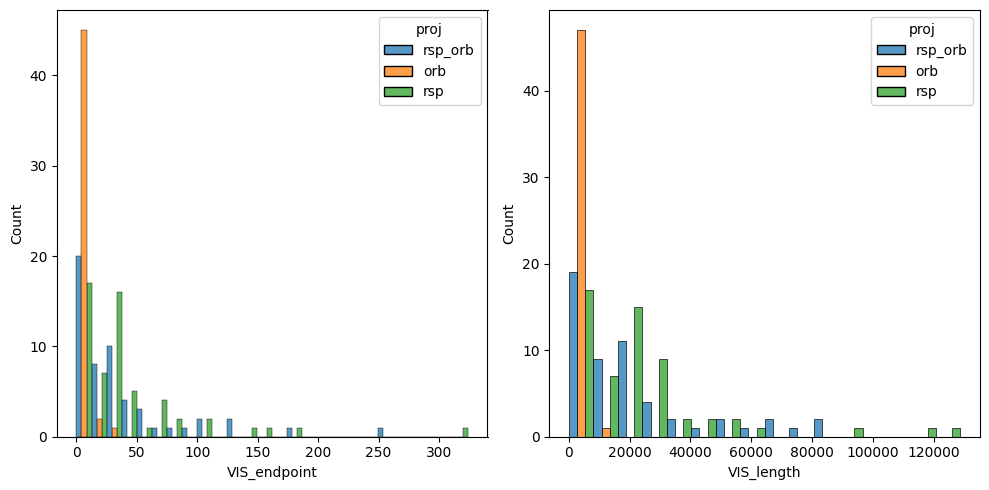

In [8]:
# Visualize the distribution of end points and lengths colored by projection type
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(data=ec_snr_data, x='VIS_endpoint', hue='proj', multiple='dodge', ax=axes[0])
sns.histplot(data=ec_snr_data, x='VIS_length', hue='proj', multiple='dodge', ax=axes[1])
plt.tight_layout()
plt.show()

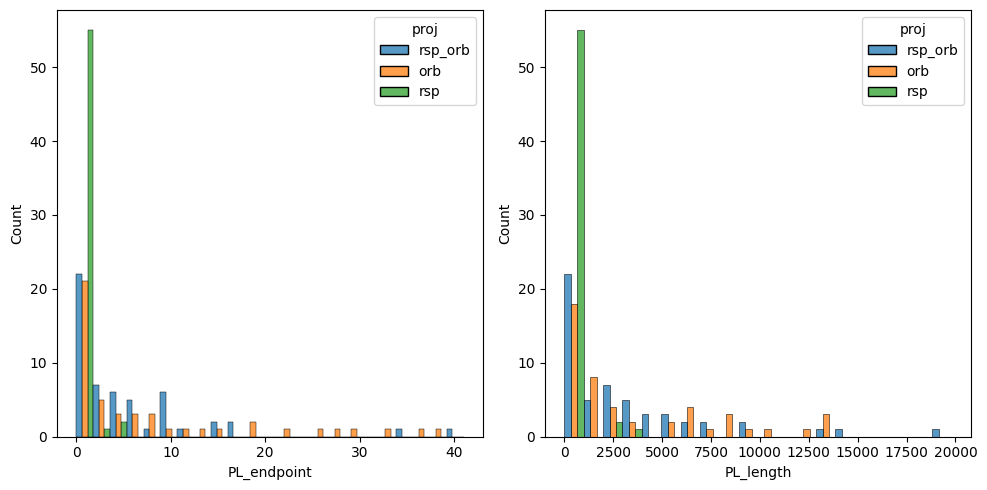

In [9]:
# Visualize the distribution of end points and lengths colored by projection type
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(data=ec_snr_data, x='PL_endpoint', hue='proj', multiple='dodge', ax=axes[0])
sns.histplot(data=ec_snr_data, x='PL_length', hue='proj', multiple='dodge', ax=axes[1])
plt.tight_layout()
plt.show()